This notebook develops several baseline forecasting models to establish benchmark performance before implementing an advanced machine learning model.

The objective is to determine whether more sophisticated algorithms provide meaningful improvements over simpler forecasting approaches.
- Create time-based train/validation/test splits
- Train baseline forecasting models
- Evaluate forecasting accuracy
- Compare model performance
- Select a benchmark for XGBoost

In [50]:
from src.utils.project_setup import *
from src.utils.config import PROCESSED_DATA
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error
)

from sklearn.linear_model import LinearRegression

In [7]:
master = pd.read_parquet(
    PROCESSED_DATA / "model_dataset.parquet"
)

master.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,week,day,dayofweek,quarter,is_weekend,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_28,price_change,price_diff,is_event,rolling_max_28,rolling_min_28
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.0,4,29,5,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.0,4,30,6,1,1,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,NaN,NaN
2,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.0,5,31,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,NaN,NaN
3,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,1,1,0,2.0,5,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,NaN,NaN
4,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,1,0,1,2.0,5,2,2,1,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,NaN,NaN


In [8]:
# Remove observations without complete feature history
model_data = master.dropna().copy()

print(f"Original dataset: {master.shape}")
print(f"Modeling dataset: {model_data.shape}")

Original dataset: (58327370, 38)
Modeling dataset: (94483, 38)


Because we created lag and rolling features, the first 28 days for each product-store combination contain NaN values. Those rows can't be used for training.

In [9]:
model_data = (
    model_data
    .sort_values("date")
    .reset_index(drop=True)
)

In [10]:
print("Start Date:", model_data["date"].min())
print("End Date:", model_data["date"].max())

Start Date: 2011-04-24 00:00:00
End Date: 2014-06-15 00:00:00


In [11]:
n = len(model_data)

train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train = model_data.iloc[:train_end]
valid = model_data.iloc[train_end:valid_end]
test = model_data.iloc[valid_end:]

In [12]:
#verifying the split
print(f"Training:   {train.shape}")
print(f"Validation: {valid.shape}")
print(f"Testing:    {test.shape}")

Training:   (66138, 38)
Validation: (14172, 38)
Testing:    (14173, 38)


In [13]:
# checking the dates to avoid any overlap in the data
print("Training")
print(train["date"].min(), "to", train["date"].max())

print("\nValidation")
print(valid["date"].min(), "to", valid["date"].max())

print("\nTesting")
print(test["date"].min(), "to", test["date"].max())

Training
2011-04-24 00:00:00 to 2014-04-20 00:00:00

Validation
2014-04-20 00:00:00 to 2014-06-15 00:00:00

Testing
2014-06-15 00:00:00 to 2014-06-15 00:00:00


In [14]:
target = "sales"

exclude = [
    "sales",
    "date",
    "id"
]

feature_columns = [
    c for c in model_data.columns
    if c not in exclude
]

X_train = train[feature_columns]
y_train = train[target]

X_valid = valid[feature_columns]
y_valid = valid[target]

X_test = test[feature_columns]
y_test = test[target]

In [15]:
print("Training")
print(X_train.shape, y_train.shape)

print()

print("Validation")
print(X_valid.shape, y_valid.shape)

print()

print("Testing")
print(X_test.shape, y_test.shape)

Training
(66138, 35) (66138,)

Validation
(14172, 35) (14172,)

Testing
(14173, 35) (14173,)


In [19]:
# Review feature data types
X_train.dtypes.astype(str).sort_values()

week                UInt32
sell_price         float64
lag_7              float64
lag_14             float64
lag_28             float64
rolling_mean_7     float64
rolling_mean_28    float64
rolling_std_28     float64
price_change       float64
price_diff         float64
rolling_max_28     float64
rolling_min_28     float64
month                int32
year                 int32
day                  int32
dayofweek            int32
quarter              int32
wm_yr_wk             int64
wday                 int64
snap_CA              int64
snap_TX              int64
snap_WI              int64
is_weekend           int64
is_event             int64
item_id                str
dept_id                str
cat_id                 str
store_id               str
state_id               str
d                      str
weekday                str
event_name_1           str
event_type_1           str
event_name_2           str
event_type_2           str
dtype: str

In [20]:
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

categorical_features

['item_id',
 'dept_id',
 'cat_id',
 'store_id',
 'state_id',
 'd',
 'weekday',
 'event_name_1',
 'event_type_1',
 'event_name_2',
 'event_type_2']

In [21]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

len(numeric_features)

24

With over 30,000 unique items, one-hot encoding item_id would create an impractically large feature matrix.

In [22]:
drop_columns = [
    "item_id"
]

X_train = X_train.drop(columns=drop_columns)
X_valid = X_valid.drop(columns=drop_columns)
X_test = X_test.drop(columns=drop_columns)

In [38]:
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)

In [25]:
X_train_processed = preprocessor.fit_transform(X_train)

X_valid_processed = preprocessor.transform(X_valid)

X_test_processed = preprocessor.transform(X_test)

In [26]:
print("Training:", X_train_processed.shape)
print("Validation:", X_valid_processed.shape)
print("Testing:", X_test_processed.shape)

Training: (66138, 60)
Validation: (14172, 60)
Testing: (14173, 60)


In [29]:
print(type(X_train_processed))

<class 'numpy.ndarray'>


In [30]:
print(X_train_processed.dtype)

object


In [31]:

X_train.isna().sum().sort_values(ascending=False).head(20)

dept_id         0
cat_id          0
store_id        0
state_id        0
d               0
wm_yr_wk        0
weekday         0
wday            0
month           0
year            0
event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
snap_CA         0
snap_TX         0
snap_WI         0
sell_price      0
week            0
day             0
dtype: int64

In [35]:
X_train.select_dtypes(exclude=["number"]).dtypes

dept_id         str
cat_id          str
store_id        str
state_id        str
d               str
weekday         str
event_name_1    str
event_type_1    str
event_name_2    str
event_type_2    str
dtype: object

In [36]:
#dropping the str values we have engineered features for these values
drop_cols = [
    "d",
    "weekday",
    "event_name_1",
    "event_name_2",
]

X_train = X_train.drop(columns=drop_cols)
X_valid = X_valid.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [59]:
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

In [66]:
seasonal_naive = valid["lag_7"]

seasonal_mae = mean_absolute_error(
    y_valid,
    seasonal_naive
)

seasonal_rmse = root_mean_squared_error(
    y_valid,
    seasonal_naive
)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 1.076
RMSE: 2.523


In [58]:
moving_average = valid["rolling_mean_7"]

moving_average_mae = mean_absolute_error(
    y_valid,
    moving_average
)

moving_average_rmse = root_mean_squared_error(
    y_valid,
    moving_average
)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 1.076
RMSE: 2.523


In [61]:
lr = LinearRegression()

lr.fit(
    X_train_processed,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](51,)","[-0. ,-0.03, 0.06,..., 0. ,-0.08, 0.25]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.4398
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,51
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,26
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](51,)","[29244.96, 3187.11, 2049.6 ,..., 0. , 0. , 0. ]"


In [62]:
lr_pred = lr.predict(
    X_valid_processed
)

lr_mae = mean_absolute_error(
    y_valid,
    lr_pred
)

lr_rmse = root_mean_squared_error(
    y_valid,
    lr_pred
)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 1.076
RMSE: 2.523


In [63]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_processed,
    y_train
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [64]:
rf_pred = rf.predict(
    X_valid_processed
)

In [65]:
rf_mae = mean_absolute_error(
    y_valid,
    rf_pred
)

rf_rmse = root_mean_squared_error(
    y_valid,
    rf_pred
)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 1.076
RMSE: 2.523


In [68]:
seasonal_naive_mae = mean_absolute_error(y_valid, seasonal_naive)
seasonal_rmse = root_mean_squared_error(y_valid, seasonal_naive)

moving_average_mae = mean_absolute_error(y_valid, moving_average)
moving_average_rmse = root_mean_squared_error(y_valid, moving_average)

lr_mae = mean_absolute_error(y_valid, lr_pred)
lr_rmse = root_mean_squared_error(y_valid, lr_pred)

rf_mae = mean_absolute_error(y_valid, rf_pred)
rf_rmse = root_mean_squared_error(y_valid, rf_pred)

In [70]:
results = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "Moving Average",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        seasonal_naive_mae,
        moving_average_mae,
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        seasonal_rmse,
        moving_average_rmse,
        lr_rmse,
        rf_rmse
    ]
})

results = results.round({
    "MAE": 3,
    "RMSE": 3
})

results

results.sort_values("RMSE")

,Model,MAE,RMSE
3,Random Forest,1.076,2.523
1,Moving Average,0.999,2.638
2,Linear Regression,1.071,2.641
0,Seasonal Naive,1.334,3.850


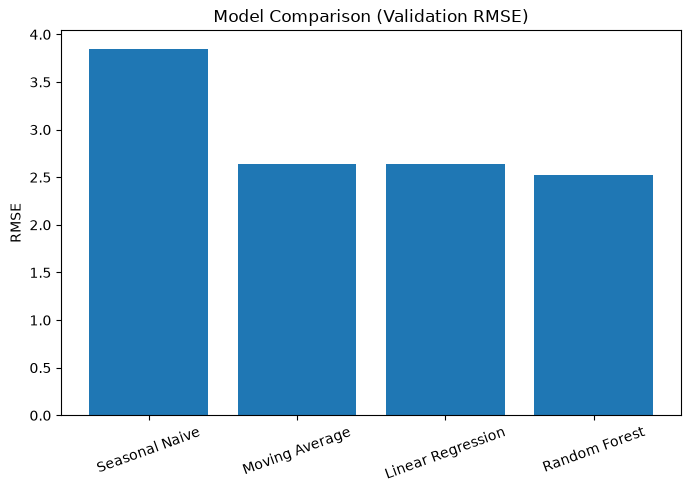

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["RMSE"])

plt.title("Model Comparison (Validation RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=20)

plt.show()

Four baseline forecasting approaches were evaluated using the validation dataset.

The Random Forest model achieved the lowest RMSE, indicating the best overall predictive performance and the smallest large forecasting errors. This suggests that non-linear relationships exist within the historical demand data and that tree-based models can effectively exploit the engineered features.

The Moving Average model achieved the lowest MAE, demonstrating that simple statistical methods remain competitive for minimizing average forecasting error. However, its higher RMSE indicates that it struggles to capture larger fluctuations in demand.

Linear Regression produced performance comparable to the Moving Average, suggesting that the engineered lag, rolling, pricing, and calendar features provide substantial predictive information even for a simple linear model.

The Seasonal Naïve approach produced the weakest results, confirming that demand patterns cannot be accurately modeled using only the previous week's sales.